In [1]:
import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

from uphate.mds import compute_metric_mds_embedding, mds_loss

# Synthetic data

We create synthetic data + embeddings, where Y is the corners of a square in 2D, and X is the same points lifted to 3D and rotated

In [2]:
Y = jnp.array(
    [
        [1, 0],
        [0, 1],
        [1, 1],
        [0, 0],
    ],
    dtype=jnp.float32,
)
X = (
    jnp.concat([Y, jnp.ones((4, 1))], axis=1)
    @ Rotation.from_euler("xyz", jnp.array([90, 45, 20]), degrees=True).as_matrix()
)

We see that the MDS loss for this data, embedding pair is ~0

In [3]:
key, subkey = jax.random.split(jax.random.PRNGKey(0))

Y_init = jax.random.normal(subkey, shape=Y.shape)
Y_hat = compute_metric_mds_embedding(Y_init, X, key)
mds_loss(Y_hat, X, None)

Array(2.6022867e-08, dtype=float32)

Since our implementation is differentiable, we can now get the jacobian of the embedding wrt the data X. We test this with 3 different initializations, which lead to 3 different solutions. However, since the last two initializations are just translations of each other, the jacobians are the same as expected.

In [4]:
jac1 = jax.jacrev(compute_metric_mds_embedding, argnums=1)(
    Y_init,
    X,
    subkey,
)
jac2 = jax.jacrev(compute_metric_mds_embedding, argnums=1)(
    Y,
    X,
    subkey,
)
jac3 = jax.jacrev(compute_metric_mds_embedding, argnums=1)(
    Y + 100,
    X,
    subkey,
)
assert jnp.abs(jac3 - jac2).max() < 1e-6

We can now visualize the gradients of the embeddings wrt certain entries of X. Here we plot two different MDS solutions and their gradients, which we can see are just shifted and rotated versions of each other.

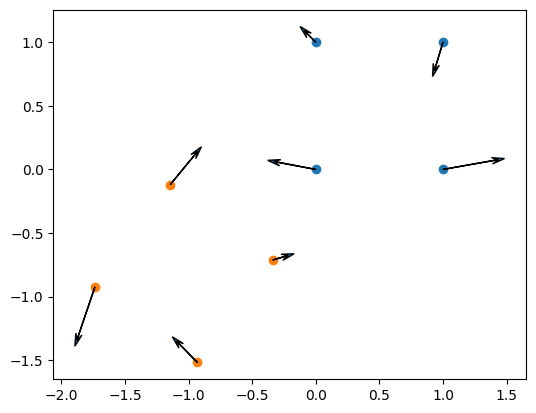

In [ ]:
# Look at derivatives w.r.t first coordinate of first entry of X
x_entry, x_coord = 0, 0
grad_y_hat = jac1[:, :, x_entry, x_coord]
grad_y = jac2[:, :, x_entry, x_coord]


fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(*Y.T)
for point, arrow in zip(Y, grad_y):
    ax.arrow(
        *point,
        *arrow,
        head_width=0.05,
        head_length=0.1,
        overhang=0.5,
    )
ax.scatter(*Y_hat.T)
for point, arrow in zip(Y_hat, grad_y_hat):
    ax.arrow(
        *point,
        *arrow,
        head_width=0.05,
        head_length=0.1,
        overhang=0.5,
    )